https://machinelearningmastery.com/building-smart-machine-learning-in-low-resource-settings/

## Smarter Crop Choices in Low-Resource Farming

#### descriptive statistics

In [10]:
import pandas as pd              # data handling
import numpy as np               # numerical ops

import matplotlib.pyplot as plt  # plotting
import seaborn as sns            # nicer plots

from scipy.stats import f_oneway # ANOVA test

In [6]:
df = pd.read_csv("Crop_recommendation.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [8]:
df.select_dtypes(include=['int64', 'float64']).describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


#### visual exploration

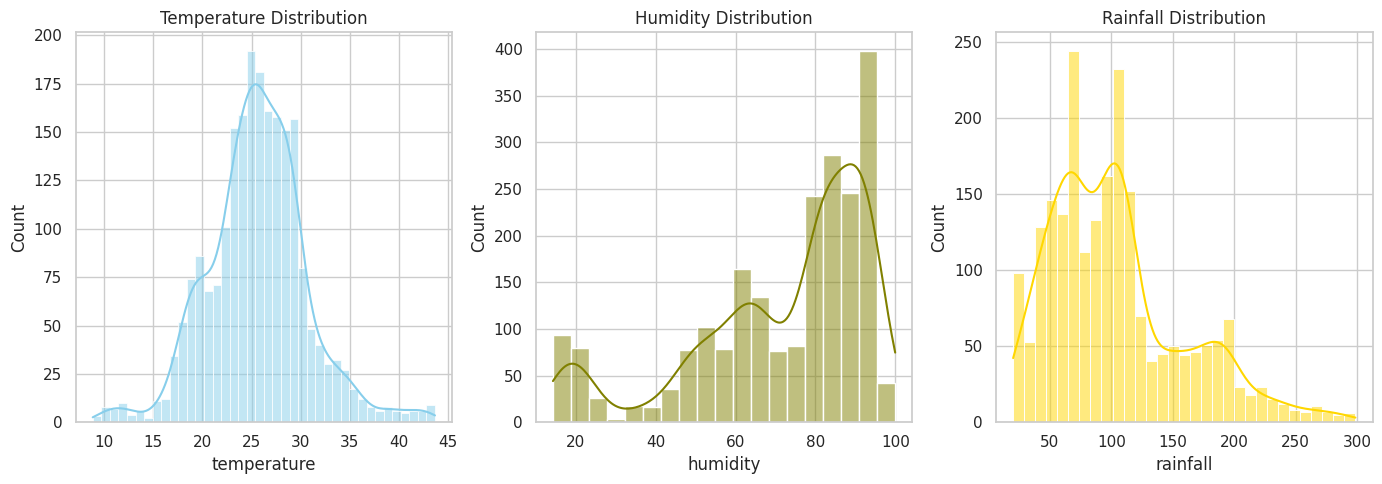

In [11]:
# Setting the aesthetic style of the plots
sns.set_theme(style="whitegrid")

# Creating visualizations for Temperature, Humidity and Rainfall
fig, axes = plt.subplots(1,3, figsize=(14,5))

# Temperature distribution
sns.histplot(df['temperature'], kde=True, color="skyblue", ax=axes[0])
axes[0].set_title("Temperature Distribution")

# Humidity Distribution
sns.histplot(df['humidity'], kde=True, color='olive', ax=axes[1])
axes[1].set_title("Humidity Distribution")

# Rainfall Distribution
sns.histplot(df['rainfall'], kde=True, color='gold', ax=axes[2])
axes[2].set_title("Rainfall Distribution")

plt.tight_layout()
plt.show()



#### ANOVA Analysis for Humidity

##### To understand how environmental factors differ across crop types

In [12]:
# Define crop_types based on DataFrame 'df'
crop_types = df['label'].unique()

# Prepare a list of humidity values for each crop type
humidity_lists = [df[df['label'] == crop] ['humidity'] for crop in crop_types]

# Performing the ANOVA test for humidity
anova_result_humidity = f_oneway(*humidity_lists)

anova_result_humidity

F_onewayResult(statistic=3103.708891217461, pvalue=0.0)

#### ANOVA Analysis for Rainfall

In [13]:
# Define crop_types based on DataFrame 'df'
crop_types_rainfall = df['label'].unique()

# Prepare a list of rainfall values for each crop type
rainfall_lists = [df[df['label'] == crop] ['rainfall'] for crop in crop_types_rainfall]

# Performing the ANOVA test for rainfall
anova_result_rainfall = f_oneway(*rainfall_lists)

anova_result_rainfall

F_onewayResult(statistic=605.5279661441423, pvalue=0.0)

#### ANOVA Analysis for Temperature

In [14]:
# Ensure crop_types is defined from your DataFrame 'df'
crop_types_temp = df['label'].unique()
 
# Preparing a list of temperature values for each crop type
temperature_lists = [df[df['label'] == crop]['temperature'] for crop in crop_types_temp]
 
# Performing the ANOVA test for temperature
anova_result_temperature = f_oneway(*temperature_lists)
 
anova_result_temperature

F_onewayResult(statistic=102.18698122995393, pvalue=4.019323818173197e-305)